In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("C:/Users/DELL/Downloads/Data/Crime data/Chicage Crime Data.csv")
df.head()

C:\Users\DELL\AppData\Local\Temp\ipykernel_11380\1932618510.py:6: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:/Users/DELL/Downloads/Data/Crime data/Chicage Crime Data.csv")


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,5741943,HN549294,08/25/2007 09:22:18 AM,074XX N ROGERS AVE,0560,ASSAULT,SIMPLE,OTHER,False,False,...,49.0,1.0,08A,NaN,NaN,2007.0,08/17/2015 03:03:40 PM,NaN,NaN,NaN
1,25953,JE240540,05/24/2021 03:06:00 PM,020XX N LARAMIE AVE,0110,HOMICIDE,FIRST DEGREE MURDER,STREET,True,False,...,36.0,19.0,01A,1141387.0,1913179.0,2021.0,11/18/2023 03:39:49 PM,41.917838,-87.755969,"(41.917838056, -87.755968972)"
2,26038,JE279849,06/26/2021 09:24:00 AM,062XX N MC CORMICK RD,0110,HOMICIDE,FIRST DEGREE MURDER,PARKING LOT,True,False,...,50.0,13.0,01A,1152781.0,1941458.0,2021.0,11/18/2023 03:39:49 PM,41.995219,-87.713355,"(41.995219444, -87.713354912)"
3,13279676,JG507211,11/09/2023 07:30:00 AM,019XX W BYRON ST,0620,BURGLARY,UNLAWFUL ENTRY,APARTMENT,False,False,...,47.0,5.0,05,1162518.0,1925906.0,2023.0,11/18/2023 03:39:49 PM,41.952345,-87.677975,"(41.952345086, -87.677975059)"
4,13274752,JG501049,11/12/2023 07:59:00 AM,086XX S COTTAGE GROVE AVE,0454,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MIN...",SMALL RETAIL STORE,True,False,...,6.0,44.0,08B,1183071.0,1847869.0,2023.0,12/09/2023 03:41:24 PM,41.737751,-87.604856,"(41.737750767, -87.604855911)"


In [5]:
df = df.dropna()
df.isnull().sum()

ID                      0
Case Number             0
Date                    0
Block                   0
IUCR                    0
Primary Type            0
Description             0
Location Description    0
Arrest                  0
Domestic                0
Beat                    0
District                0
Ward                    0
Community Area          0
FBI Code                0
X Coordinate            0
Y Coordinate            0
Year                    0
Updated On              0
Latitude                0
Longitude               0
Location                0
dtype: int64

In [6]:
#df.to_csv("C:/Users/DELL/Downloads/Crime data/crime_data_cleaned.csv", index=False)
#"C:\Users\DELL\Downloads\Crime data"
df.shape

(6704462, 22)

In [7]:
df['Year'] = df['Year'].astype(int)


In [8]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Time'] = df['Date'].dt.time
df['Hours'] = df['Time'].astype(str).str.zfill(4).str[:2].astype(int)





C:\Users\DELL\AppData\Local\Temp\ipykernel_11380\2136674645.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [9]:
df.to_csv("C:/Users/DELL/Downloads/Crime data\crime_data_cleaned.csv", index=False)

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\DELL\AppData\Local\Temp\ipykernel_11380\2110645321.py:1: SyntaxWarning: invalid escape sequence '\c'
  df.to_csv("C:/Users/DELL/Downloads/Crime data\crime_data_cleaned.csv", index=False)
C:\Users\DELL\AppData\Local\Temp\ipykernel_11380\2110645321.py:1: SyntaxWarning: invalid escape sequence '\c'
  df.to_csv("C:/Users/DELL/Downloads/Crime data\crime_data_cleaned.csv", index=False)


OSError: Cannot save file into a non-existent directory: 'C:\Users\DELL\Downloads\Crime data'

In [ ]:
# Crime Rate over the years
sns.countplot(data=df, x = df['Year'])
plt.figure(figsize=(10,5))
plt.title('Crime Rate Over THe Years')
plt.xlabel('Year')
plt.ylabel('')
plt.show()

NameError: name 'sns' is not defined

In [ ]:
df.columns.tolist()

['ID',
 'Case Number',
 'Date',
 'Block',
 'IUCR',
 'Primary Type',
 'Description',
 'Location Description',
 'Arrest',
 'Domestic',
 'Beat',
 'District',
 'Ward',
 'Community Area',
 'FBI Code',
 'X Coordinate',
 'Y Coordinate',
 'Year',
 'Updated On',
 'Latitude',
 'Longitude',
 'Location']

In [ ]:
df.loc[:3, ['Block', 'Location Description', 'District','Community Area', 'Ward']]

,Block,Location Description,District,Community Area,Ward
1,020XX N LARAMIE AVE,STREET,25.0,19.0,36.0
2,062XX N MC CORMICK RD,PARKING LOT,17.0,13.0,50.0
3,019XX W BYRON ST,APARTMENT,19.0,5.0,47.0


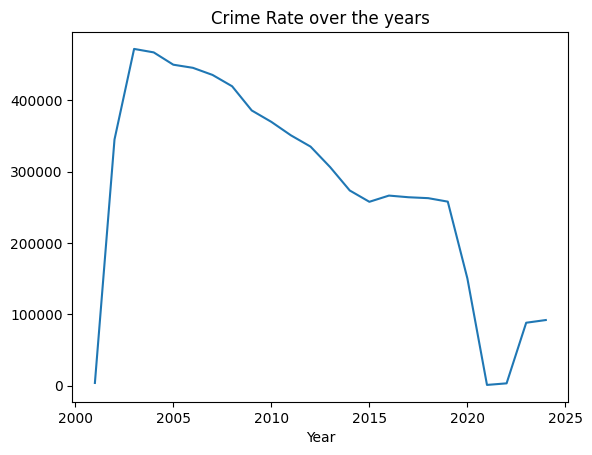

In [ ]:
line = df[['ID', 'Year']]
line_plot = line['Year'].value_counts().sort_index().reset_index()
line_plot.columns = ['Year', 'Count']
sns.lineplot(data=line_plot, x = 'Year', y = 'Count')
plt.title('Crime Rate over the years')
plt.xlabel('Year')
plt.ylabel('')
plt.show()


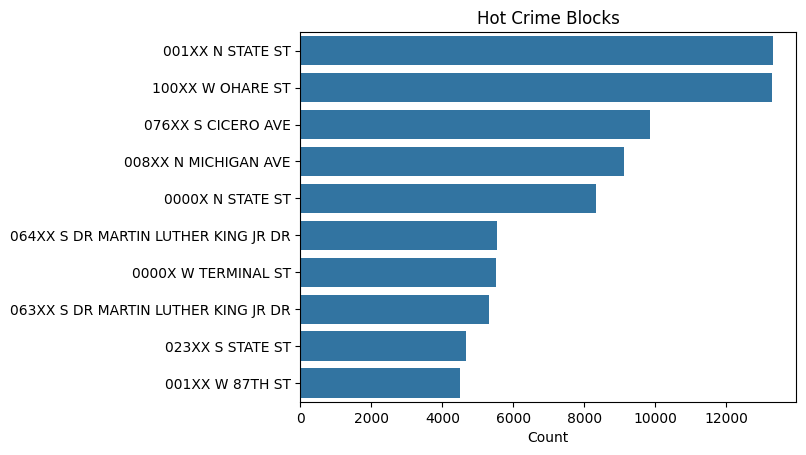

In [ ]:
# Hot Crime Blocks
block = df[['Block']]
block = block['Block'].value_counts().reset_index()
block.columns = ['Block', 'Count']
sns.barplot(data=block.head(10), y ='Block', x= 'Count')
plt.title('Hot Crime Blocks')
plt.ylabel('')
plt.show()



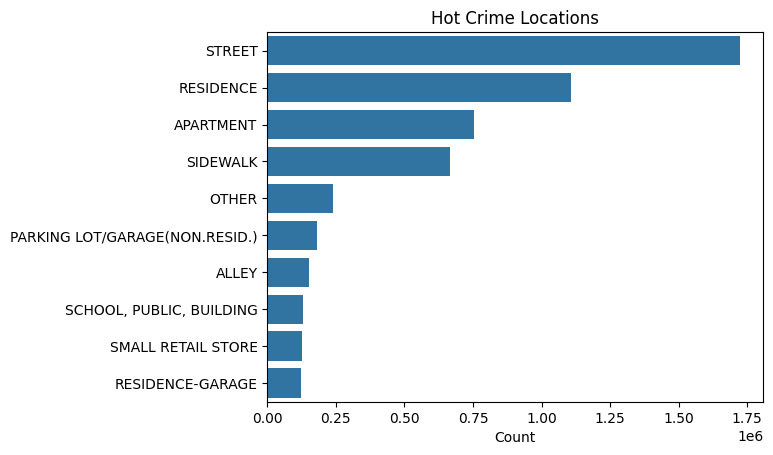

In [ ]:
# Hot Crime Location
Location = df[['Location Description']]
Location = Location['Location Description'].value_counts().reset_index()
Location.columns = ['Location Description', 'Count']
sns.barplot(data=Location.head(10), y ='Location Description', x= 'Count')
plt.title('Hot Crime Locations')
plt.ylabel('')
plt.show()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6704462 entries, 1 to 7391185
Data columns (total 22 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Case Number           object 
 2   Date                  object 
 3   Block                 object 
 4   IUCR                  object 
 5   Primary Type          object 
 6   Description           object 
 7   Location Description  object 
 8   Arrest                object 
 9   Domestic              object 
 10  Beat                  float64
 11  District              float64
 12  Ward                  float64
 13  Community Area        float64
 14  FBI Code              object 
 15  X Coordinate          float64
 16  Y Coordinate          float64
 17  Year                  int64  
 18  Updated On            object 
 19  Latitude              float64
 20  Longitude             float64
 21  Location              object 
dtypes: float64(8), int64(2), object(12)
memory usag

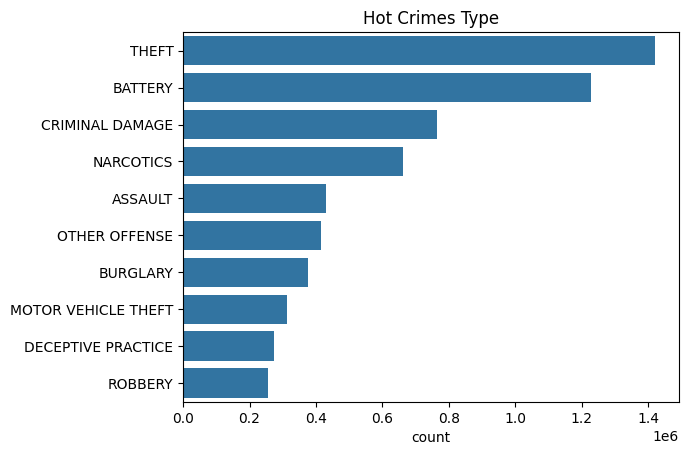

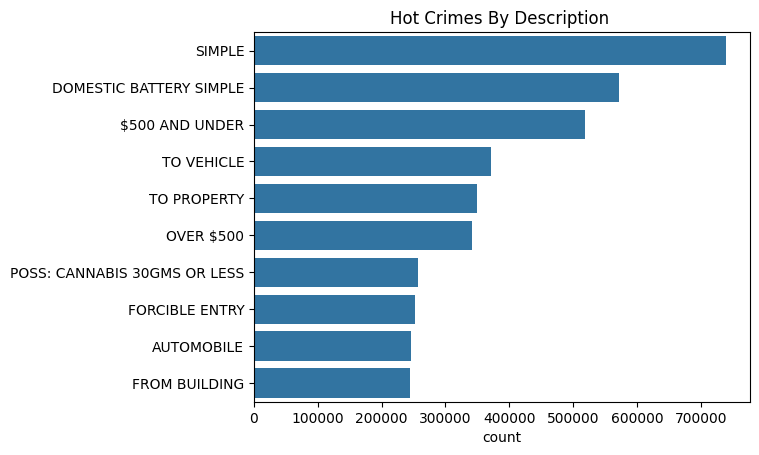

In [ ]:
#Top Crimes
crime = df[['Primary Type','Description']]
crime_prime = crime['Primary Type'].value_counts().reset_index()
crime_desc = crime['Description'].value_counts().reset_index()

sns.barplot(data=crime_prime.head(10), y ='Primary Type', x= 'count')
plt.title('Hot Crimes Type')
plt.ylabel('')
plt.show()


sns.barplot(data=crime_desc.head(10), y ='Description', x= 'count')
plt.title('Hot Crimes By Description ')
plt.ylabel('')
plt.show()





In [ ]:
df[['Arrest', 'Beat','FBI Code','Updated On']]

,Arrest,Beat,FBI Code,Updated On
1,True,2515.0,01A,11/18/2023 03:39:49 PM
2,True,1711.0,01A,11/18/2023 03:39:49 PM
3,False,1922.0,05,11/18/2023 03:39:49 PM
4,True,632.0,08B,12/09/2023 03:41:24 PM
6,False,122.0,14,11/04/2023 03:40:18 PM
...,...,...,...,...
7391181,False,1911.0,14,09/29/2020 03:42:13 PM
7391182,False,421.0,08A,07/02/2020 03:42:11 PM
7391183,False,322.0,14,10/17/2020 03:40:42 PM
7391184,False,1731.0,06,07/21/2020 03:43:27 PM
